## 1. Imports and global configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import re
import html
import unicodedata
import warnings
import time


from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    average_precision_score,
    roc_auc_score
)
from sklearn.model_selection import KFold, cross_validate, cross_val_predict, train_test_split, RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    make_scorer,
    median_absolute_error,
    explained_variance_score,
)
from scipy.stats import spearmanr, pearsonr
from xgboost import XGBRegressor




## 2. Locate and load the raw JSON files

In [119]:
# find the raw json files

json_dir = Path("../../raw_new")

# to skip the tracker metadata file
json_files = sorted([
    p for p in json_dir.glob("*.json")
    if "scraped_videos_tracker" not in p.name
])

print("JSON directory:", json_dir.resolve())
print("Number of JSON files found:", len(json_files))
print([p.name for p in json_files[:5]])


JSON directory: /Users/hargun/Desktop/data-science/EarlySlangDetection/raw_new
Number of JSON files found: 75
['1STUD_batch_20260615_220936.json', '1STUD_batch_20260616_120929.json', '1STUD_batch_20260616_125913.json', '1STUD_batch_20260629_221901.json', 'AsmonTV_batch_20260608_205250.json']


In [120]:
# load the raw comment files

dfs = []

for json_file in json_files:
    temp = pd.read_json(json_file)
    temp["channel_name"] = json_file.stem.split("_batch_")[0].replace("(1)", "")

    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

# basic cleanup
df["published_at"] = pd.to_datetime(df["published_at"], utc=True, errors="coerce")
df["likes"] = pd.to_numeric(df["likes"], errors="coerce").fillna(0).clip(lower=0).astype(int)
df["text"] = df["text"].fillna("").astype(str)

# no timestamp means no week assignment
df = df.dropna(subset=["published_at"]).reset_index(drop=True)

# simple comment id after cleaning
df["comment_id"] = df.index

display(df.head())
df.info()

print("Raw comments:", len(df))
print("Unique videos:", df["video_id"].nunique())
print("Unique channels:", df["channel_name"].nunique())


,video_id,text,likes,published_at,channel_name,comment_id
0,BSv6hna2Ycs,3:22 zenin clan treatment,49,2026-06-15 11:44:27+00:00,1STUD,0
1,BSv6hna2Ycs,your goat stud i wacht you 4 years,29,2026-06-15 11:03:58+00:00,1STUD,1
2,BSv6hna2Ycs,I WATCHED YA FOR 2 YEARS!!!,6,2026-06-15 12:03:19+00:00,1STUD,2
3,BSv6hna2Ycs,2:21 Bro Noob Army Being Like God Slayer😂,3,2026-06-15 14:31:33+00:00,1STUD,3
4,BSv6hna2Ycs,Yo stud even though you probably not going to ...,3,2026-06-15 14:24:59+00:00,1STUD,4


<class 'pandas.DataFrame'>
RangeIndex: 1739328 entries, 0 to 1739327
Data columns (total 6 columns):
 #   Column        Dtype              
---  ------        -----              
 0   video_id      str                
 1   text          str                
 2   likes         int64              
 3   published_at  datetime64[us, UTC]
 4   channel_name  str                
 5   comment_id    int64              
dtypes: datetime64[us, UTC](1), int64(2), str(3)
memory usage: 79.6 MB
Raw comments: 1739328
Unique videos: 19517
Unique channels: 32


## 3. Create the 20-week observation window

In [121]:
NUM_WEEKS = 20
FUTURE_WEEKS = 3

# assign each comment to a week

latest = df["published_at"].max()

# week_back = 0 means most recent week.
# week_back = 1 means one week before the most recent week.
df["week_back"] = ((latest - df["published_at"]).dt.days // 7).astype(int)

# keep the most recent 20 weeks
df = df[(df["week_back"] >= 0) & (df["week_back"] < NUM_WEEKS)].copy().reset_index(drop=True)

# reset ids after filtering
df["comment_id"] = df.index

# make time_id run from old -> new
df["time_id"] = df["week_back"].max() - df["week_back"]

display(df[["comment_id", "published_at", "week_back", "time_id", "text", "likes"]].head())

print("Comments in 20-week window:", len(df))
print("time_id range:", df["time_id"].min(), "to", df["time_id"].max())


,comment_id,published_at,week_back,time_id,text,likes
0,0,2026-06-15 11:44:27+00:00,2,17,3:22 zenin clan treatment,49
1,1,2026-06-15 11:03:58+00:00,2,17,your goat stud i wacht you 4 years,29
2,2,2026-06-15 12:03:19+00:00,2,17,I WATCHED YA FOR 2 YEARS!!!,6
3,3,2026-06-15 14:31:33+00:00,2,17,2:21 Bro Noob Army Being Like God Slayer😂,3
4,4,2026-06-15 14:24:59+00:00,2,17,Yo stud even though you probably not going to ...,3


Comments in 20-week window: 373517
time_id range: 0 to 19


## 4. Tokenize comments

In [ ]:
TOKEN_RE = re.compile(
    r"""
    (?<![a-z0-9])
    \#?
    (?:
        [a-z]+(?:['’‘ʼ`´＇-][a-z]+)*[a-z0-9]*
        |
        [a-z]*\d+[a-z0-9]*
    )
    (?![a-z0-9])
    """,
    re.I | re.VERBOSE
)

URL_RE = re.compile(r"https?://\S+|www\.\S+")
TIME_RE = re.compile(r"\b\d{1,2}:\d{2}(?::\d{2})?\b")

APOSTROPHE_TRANSLATION = str.maketrans({
    "’": "'",
    "‘": "'",
    "ʼ": "'",
    "`": "'",
    "´": "'",
    "＇": "'"
})

def tokenize(text):
    """Basic tokenizer for comment text."""
    text = html.unescape(str(text))
    text = unicodedata.normalize("NFKC", text)
    text = text.translate(APOSTROPHE_TRANSLATION)
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = TIME_RE.sub(" ", text)

    tokens = [m.group(0).lstrip("#") for m in TOKEN_RE.finditer(text)]

    # Remove tokens that are only digits
    tokens = [t for t in tokens if not t.isdigit()]

    return tokens

df["tokens"] = df["text"].apply(tokenize)

display(df[["text", "tokens"]].sample(10, random_state=42))


,text,tokens
115493,Day 7 of asking for a fractal block world theory,"[day, of, asking, for, a, fractal, block, worl..."
247243,Interesting,[interesting]
179793,“as of 2024” okay. so wheres the updated chart?,"[as, of, okay, so, wheres, the, updated, chart]"
329339,"Ryan Cohen, trust the process","[ryan, cohen, trust, the, process]"
370479,Hissan wouldve captured this guy easy once the...,"[hissan, wouldve, captured, this, guy, easy, o..."
175703,Imagine jumping as a casual Morse code for bei...,"[imagine, jumping, as, a, casual, morse, code,..."
256504,The whole game in one trailer!!! Nice,"[the, whole, game, in, one, trailer, nice]"
157569,28:37 TIMMEH????,[timmeh]
362904,We’ve seen this already bro ♻️,"[we've, seen, this, already, bro]"
194213,Continue Playing Red Dead Redemption 2 we all ...,"[continue, playing, red, dead, redemption, we,..."


## 5. Create one word occurrence per comment

A word is counted once per comment, even if it appears multiple times.

In [ ]:
# splitting comment into individual words

df_words = df.explode("tokens").rename(columns={"tokens": "word"})
df_words = df_words.dropna(subset=["word"])
df_words = df_words[df_words["word"].str.len() > 0].copy()

# count a word only once per comment
df_unique = df_words.drop_duplicates(["comment_id", "word", "time_id"])

display(df_words[["comment_id", "word", "likes", "time_id", "video_id"]].head())
display(df_unique[["comment_id", "word", "likes", "time_id", "video_id"]].head())

print("Word occurrences before de-duplication:", len(df_words))
print("Unique comment-word-week rows after de-duplication:", len(df_unique))


,comment_id,word,likes,time_id,video_id
0,0,zenin,49,17,BSv6hna2Ycs
0,0,clan,49,17,BSv6hna2Ycs
0,0,treatment,49,17,BSv6hna2Ycs
1,1,your,29,17,BSv6hna2Ycs
1,1,goat,29,17,BSv6hna2Ycs


,comment_id,word,likes,time_id,video_id
0,0,zenin,49,17,BSv6hna2Ycs
0,0,clan,49,17,BSv6hna2Ycs
0,0,treatment,49,17,BSv6hna2Ycs
1,1,your,29,17,BSv6hna2Ycs
1,1,goat,29,17,BSv6hna2Ycs


Word occurrences before de-duplication: 4765317
Unique comment-word-week rows after de-duplication: 4252512


## 6. Build the stopword list

In [ ]:
stopwords = set("""
a about above after again against all am an and any are as at be because been before being below between both but by
can cannot could did do does doing down during each few for from further had has have having he her here hers herself
him himself his how i if in into is it its itself just me more most my myself no nor not of off on once only or other
our ours ourselves out over own same she should so some such than that the their theirs them themselves then there
these they this those through to too under until up very was we were what when where which while who whom why will
with you your yours yourself yourselves
""".split())

stopwords |= {
    "i'm","it's","that's","don't","you're","he's","she's","we're","they're",
    "i've","you've","we've","they've","i'll","you'll","we'll","they'll",
    "isn't","aren't","wasn't","weren't","can't","couldn't","wouldn't",
    "shouldn't","won't","didn't","doesn't","haven't","hasn't","hadn't",
    "there's","what's","who's","where's","when's","why's","how's",
    "im","ive","dont","cant","wont","youre","thats","theres","whats",
    "hes","shes","were","theyre","ll","re","ve","ur","amp"
}

stopwords |= {
    "would","one","get","even","video","go","know","never","got","good",
    "make","made","see","think","really","still","also","much","going",
    "people","bro","man","guys","time","way","back","first","last",
    "like","game","person","now","years","guy","kid","thing","stuff",
    "day","watch","look","looks","say","said","right","actually"
}



# Part I — Word-level dataframe construction

## 7. Build weekly word matrices

In [ ]:
# Build one-row-per-word feature table

weeks = list(range(NUM_WEEKS))

feature_weeks = list(range(NUM_WEEKS - FUTURE_WEEKS))

future_weeks = list(range(NUM_WEEKS - FUTURE_WEEKS, NUM_WEEKS))

eps_count = 1.0
eps_rel = 1e-10


weekly_comments = (
    df.groupby("time_id")["comment_id"]
    .nunique()
    .reindex(weeks)
    .fillna(0)
)

weekly_likes = (
    df.groupby("time_id")["likes"]
    .sum()
    .reindex(weeks)
    .fillna(0)
)


# Helper to make word x week matrices
def word_week_matrix(values=None, aggfunc="size"):
    if aggfunc == "size":
        mat = (
            df_unique
            .groupby(["word", "time_id"])
            .size()
            .unstack("time_id")
        )
    else:
        mat = (
            df_unique
            .pivot_table(
                index="word",
                columns="time_id",
                values=values,
                aggfunc=aggfunc
            )
        )

    mat = mat.reindex(columns=weeks).fillna(0)
    return mat


# Raw word-week matrices
count_mat = word_week_matrix(aggfunc="size")
likes_mat = word_week_matrix(values="likes", aggfunc="sum")
avg_likes_mat = word_week_matrix(values="likes", aggfunc="mean")
n_videos_mat = word_week_matrix(values="video_id", aggfunc=pd.Series.nunique)
n_channels_mat = word_week_matrix(values="channel_name", aggfunc=pd.Series.nunique)

avg_likes_mat = avg_likes_mat.fillna(0)
n_videos_mat = n_videos_mat.fillna(0)
n_channels_mat = n_channels_mat.fillna(0)

# Relative frequency and relative likes
rel_freq_mat = count_mat.div(weekly_comments.replace(0, np.nan), axis=1).fillna(0)
rel_likes_mat = likes_mat.div(weekly_likes.replace(0, np.nan), axis=1).fillna(0)


## 8. Filter the words and assemble the wide table

Words must:

- not be stopwords,
- contain at least two characters, except `w` and `l`,
- appear at least five times in at least one week.

In [127]:
before_words = len(count_mat)

valid_words = [
    w for w in count_mat.index
    if (w not in stopwords) and (len(w) >= 2 or w in {"w", "l"})
]

count_mat = count_mat.loc[valid_words]
likes_mat = likes_mat.loc[valid_words]
avg_likes_mat = avg_likes_mat.loc[valid_words]
n_videos_mat = n_videos_mat.loc[valid_words]
n_channels_mat = n_channels_mat.loc[valid_words]
rel_freq_mat = rel_freq_mat.loc[valid_words]
rel_likes_mat = rel_likes_mat.loc[valid_words]

# keep words that appear at least 5 times in at least one week
keep_words = count_mat.index[count_mat.max(axis=1) >= 5]

count_mat = count_mat.loc[keep_words]
likes_mat = likes_mat.loc[keep_words]
avg_likes_mat = avg_likes_mat.loc[keep_words]
n_videos_mat = n_videos_mat.loc[keep_words]
n_channels_mat = n_channels_mat.loc[keep_words]
rel_freq_mat = rel_freq_mat.loc[keep_words]
rel_likes_mat = rel_likes_mat.loc[keep_words]

print("Unique words before filtering:", before_words)
print("Unique words after filtering:", len(keep_words))

# Make one wide dataframe
wide_parts = []

for name, mat in {
    "count": count_mat,
    "likes": likes_mat,
    "avg_likes": avg_likes_mat,
    "n_videos": n_videos_mat,
    "n_channels": n_channels_mat,
    "rel_freq": rel_freq_mat,
    "rel_likes": rel_likes_mat,
}.items():
    temp = mat.copy()
    temp.columns = [f"week_{i}_{name}" for i in temp.columns]
    wide_parts.append(temp)

wide = pd.concat(wide_parts, axis=1).fillna(0)

print("wide shape:", wide.shape)

Unique words before filtering: 11003
Unique words after filtering: 11003
wide shape: (11003, 140)


## 9. Define the regression target

The target is

$$
y
=
\log\left(
\frac{
\text{average relative frequency in weeks 17--19}+\varepsilon
}{
\text{average relative frequency in weeks 0--16}+\varepsilon
}
\right).
$$
where $\varepsilon = 10^{-10}$.



In [128]:
# Target y
# X uses feature_weeks
# y uses future_weeks
past_rel_cols = [f"week_{i}_rel_freq" for i in feature_weeks]
future_rel_cols = [f"week_{i}_rel_freq" for i in future_weeks]

past_avg = wide[past_rel_cols].mean(axis=1)
future_avg = wide[future_rel_cols].mean(axis=1)

y = np.log((future_avg + eps_rel) / (past_avg + eps_rel))

## 10. Engineer model features using weeks 0–16 only

In [129]:
# Build X from feature_weeks only
features = {}

base_vars = [
    "count",
    "likes",
    "avg_likes",
    "n_videos",
    "n_channels",
    "rel_freq",
    "rel_likes",
]

# raw histories
for var in base_vars:
    for i in feature_weeks:
        features[f"week_{i}_{var}"] = wide[f"week_{i}_{var}"]

# log growth features
for var in ["count", "likes", "avg_likes", "n_videos", "n_channels"]:
    for i in feature_weeks[1:]:
        features[f"{var}_log_growth_{i}_{i-1}"] = np.log(
            (wide[f"week_{i}_{var}"] + eps_count)
            / (wide[f"week_{i-1}_{var}"] + eps_count)
        )

for var in ["rel_freq", "rel_likes"]:
    for i in feature_weeks[1:]:
        features[f"{var}_log_growth_{i}_{i-1}"] = np.log(
            (wide[f"week_{i}_{var}"] + eps_rel)
            / (wide[f"week_{i-1}_{var}"] + eps_rel)
        )

# likes per comment
for i in feature_weeks:
    features[f"likes_per_comment_{i}"] = (
        wide[f"week_{i}_likes"] / (wide[f"week_{i}_count"] + eps_count)
    )

# summary features
count_cols = [f"week_{i}_count" for i in feature_weeks]
rel_cols = [f"week_{i}_rel_freq" for i in feature_weeks]
like_cols = [f"week_{i}_likes" for i in feature_weeks]
video_cols = [f"week_{i}_n_videos" for i in feature_weeks]
channel_cols = [f"week_{i}_n_channels" for i in feature_weeks]

features["weeks_nonzero"] = (wide[count_cols] > 0).sum(axis=1)

features["count_mean"] = wide[count_cols].mean(axis=1)
features["count_std"] = wide[count_cols].std(axis=1)
features["count_max"] = wide[count_cols].max(axis=1)

features["rel_freq_mean"] = wide[rel_cols].mean(axis=1)
features["rel_freq_std"] = wide[rel_cols].std(axis=1)
features["rel_freq_max"] = wide[rel_cols].max(axis=1)

features["likes_mean"] = wide[like_cols].mean(axis=1)
features["likes_std"] = wide[like_cols].std(axis=1)
features["likes_max"] = wide[like_cols].max(axis=1)

features["n_videos_mean"] = wide[video_cols].mean(axis=1)
features["n_videos_max"] = wide[video_cols].max(axis=1)

# recent momentum
recent_weeks = feature_weeks[-3:]
prev_weeks = feature_weeks[-6:-3]

features["rel_freq_recent3_mean"] = wide[[f"week_{i}_rel_freq" for i in recent_weeks]].mean(axis=1)
features["rel_freq_prev3_mean"] = wide[[f"week_{i}_rel_freq" for i in prev_weeks]].mean(axis=1)
features["rel_freq_momentum_3w"] = (
    features["rel_freq_recent3_mean"] - features["rel_freq_prev3_mean"]
)

features["likes_recent3_mean"] = wide[[f"week_{i}_likes" for i in recent_weeks]].mean(axis=1)
features["likes_prev3_mean"] = wide[[f"week_{i}_likes" for i in prev_weeks]].mean(axis=1)
features["likes_momentum_3w"] = (
    features["likes_recent3_mean"] - features["likes_prev3_mean"]
)

# slopes
week_nums = np.array(feature_weeks)

def slope(row):
    return np.polyfit(week_nums, row.values, 1)[0]

features["rel_freq_slope"] = wide[rel_cols].apply(slope, axis=1)
features["count_slope"] = wide[count_cols].apply(slope, axis=1)
features["likes_slope"] = wide[like_cols].apply(slope, axis=1)

X = pd.DataFrame(features, index=wide.index)
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y summary:")
print(y.describe())



X shape: (11003, 269)
y shape: (11003,)
y summary:
count    11003.000000
mean        -2.510809
std          4.901129
min        -16.230565
25%         -1.806201
50%         -0.697033
75%         -0.052784
max         16.050188
dtype: float64


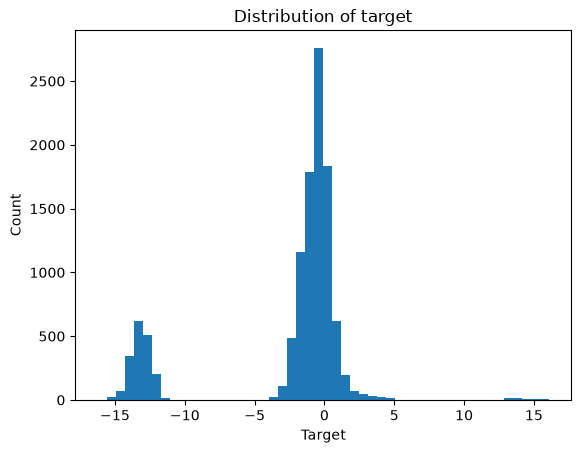

In [ ]:
#histogram plot of y values
plt.hist(y, bins=50)
plt.xlabel("Target")
plt.ylabel("Count")
plt.title("Distribution of target")
plt.show()

## 11. Filter target outliers and create the held-out split

The held-out test set is not used for model selection, hyperparameter tuning, or classification-threshold selection.

Remaining samples: 9167
count    9167.000000
mean       -0.516468
std         1.043402
min        -4.275009
25%        -1.159100
50%        -0.485948
75%         0.045163
max         6.268784
dtype: float64
count    7333.000000
mean       -0.510473
std         1.050657
min        -4.275009
25%        -1.150351
50%        -0.483541
75%         0.046478
max         6.268784
dtype: float64


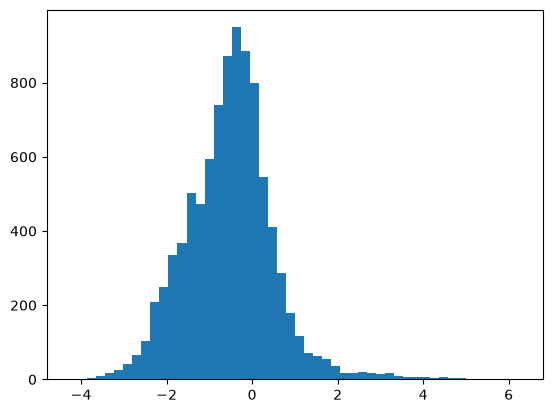

In [ ]:
# Keep only observations with target between -8 and 8
mask = (y >= -8) & (y <= 8)

X = X.loc[mask].copy()
y = y.loc[mask].copy()

print(f"Remaining samples: {len(y)}")
print(y.describe())
plt.hist(y, bins = 50)

#train-test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(y_train.describe())

# Part II — Model selection

## 12. Cross-validation design and scoring

- Inner 3-fold CV tunes hyperparameters.
- Outer 5-fold CV estimates the performance of the complete tuning process.
- The held-out test set remains untouched.

In [130]:
#nested cross-validation

inner_cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

outer_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def spearman_score(y_true, y_pred):
    return spearmanr(y_true, y_pred).statistic

def pearson_score(y_true, y_pred):
    return pearsonr(y_true, y_pred)[0]

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "medae": make_scorer(
        median_absolute_error,
        greater_is_better=False,
    ),
    "r2": "r2",
    "explained_variance": make_scorer(
        explained_variance_score
    ),
    "spearman": make_scorer(spearman_score),
    "pearson": make_scorer(pearson_score),
}

## 13. Candidate models and hyperparameter spaces

In [ ]:
from scipy.stats import loguniform, randint, uniform

fixed_models = {
    "dummy_mean": DummyRegressor(strategy="mean"),

    "dummy_median": DummyRegressor(strategy="median"),

    "linear": make_pipeline(
        StandardScaler(),
        LinearRegression()
    ),
}

tuning_models = {
    "ridge": {
        "model": make_pipeline(
            StandardScaler(),
            Ridge()
        ),
        "params": {
            "ridge__alpha": loguniform(1e-4, 1e4)
        },
        "n_iter": 20
    },

    "lasso": {
        "model": make_pipeline(
            StandardScaler(),
            Lasso(max_iter=20000)
        ),
        "params": {
            "lasso__alpha": loguniform(1e-5, 1e1)
        },
        "n_iter": 20
    },

    "random_forest": {
        # Keep this at 1 because outer CV is parallelized below
        "model": RandomForestRegressor(
            random_state=42,
            n_jobs=1
        ),
        "params": {
            "n_estimators": randint(200, 701),
            "max_depth": [6, 10, 14, 18, None],
            "min_samples_leaf": randint(1, 8),
            "min_samples_split": randint(2, 16),
            "max_features": ["sqrt", "log2", 0.5, 0.75, 1.0],
            "bootstrap": [True, False],
        },
        "n_iter": 20
    },

    "extra_trees": {
        "model": ExtraTreesRegressor(
            random_state=42,
            n_jobs=1
        ),
        "params": {
            "n_estimators": randint(200, 701),
            "max_depth": [6, 10, 14, 18, None],
            "min_samples_leaf": randint(1, 8),
            "min_samples_split": randint(2, 16),
            "max_features": ["sqrt", "log2", 0.5, 0.75, 1.0],
            "bootstrap": [False, True],
        },
        "n_iter": 20
    },

    "hist_gradient_boosting": {
        "model": HistGradientBoostingRegressor(
            random_state=42
        ),
        "params": {
            "max_iter": randint(200, 701),
            "learning_rate": loguniform(0.01, 0.15),
            "max_leaf_nodes": [15, 31, 63],
            "max_depth": [None, 3, 5, 8],
            "min_samples_leaf": randint(10, 61),
            "l2_regularization": loguniform(1e-4, 10),
        },
        "n_iter": 20
    },

    "xgboost": {
        "model": XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=1
        ),
        "params": {
            "n_estimators": randint(300, 901),
            "max_depth": randint(3, 8),
            "learning_rate": loguniform(0.008, 0.12),
            "subsample": uniform(0.65, 0.35),
            "colsample_bytree": uniform(0.65, 0.35),
            "reg_lambda": loguniform(0.1, 10),
            "reg_alpha": loguniform(1e-4, 1),
            "min_child_weight": randint(1, 8),
        },
        "n_iter": 25
    },
}

## 14. Nested cross-validation

In [ ]:
nested_rows = []

for name, model in fixed_models.items():
    print(f"Evaluating {name}...")

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=outer_cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    nested_rows.append({
        "model": name,
        "tuned": False,

        "nested_rmse_mean": -scores["test_rmse"].mean(),
        "nested_rmse_std": scores["test_rmse"].std(),

        "nested_mae_mean": -scores["test_mae"].mean(),
        "nested_mae_std": scores["test_mae"].std(),

        "nested_r2_mean": scores["test_r2"].mean(),
        "nested_r2_std": scores["test_r2"].std(),

        "nested_spearman_mean": scores["test_spearman"].mean(),
        "nested_spearman_std": scores["test_spearman"].std(),

        "nested_pearson_mean": scores["test_pearson"].mean(),
        "nested_pearson_std": scores["test_pearson"].std(),
    })

Evaluating dummy_mean...
Evaluating dummy_median...
Evaluating linear...


In [ ]:
for name, item in tuning_models.items():
    print(f"Tuning {name}...")

    search = RandomizedSearchCV(
        estimator=item["model"],
        param_distributions=item["params"],
        n_iter=item["n_iter"],
        scoring="neg_root_mean_squared_error",
        cv=inner_cv,
        random_state=42,

        # Avoid nested parallelism:
        # search runs sequentially inside each outer fold
        n_jobs=1,

        refit=True,
        verbose=1
    )

    scores = cross_validate(
        search,
        X_train,
        y_train,
        cv=outer_cv,
        scoring=scoring,

        # Parallelize the five outer folds
        n_jobs=-1,

        return_train_score=False,
        return_estimator=True
    )

    nested_rows.append({
        "model": name,
        "tuned": True,

        "nested_rmse_mean": -scores["test_rmse"].mean(),
        "nested_rmse_std": scores["test_rmse"].std(),

        "nested_mae_mean": -scores["test_mae"].mean(),
        "nested_mae_std": scores["test_mae"].std(),

        "nested_r2_mean": scores["test_r2"].mean(),
        "nested_r2_std": scores["test_r2"].std(),

        "nested_spearman_mean": scores["test_spearman"].mean(),
        "nested_spearman_std": scores["test_spearman"].std(),

        "nested_pearson_mean": scores["test_pearson"].mean(),
        "nested_pearson_std": scores["test_pearson"].std(),
    })

Tuning ridge...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Tuning lasso...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Tuning random_forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Tuning extra_trees...
Fitting

In [ ]:
nested_results = (
    pd.DataFrame(nested_rows)
    .sort_values("nested_rmse_mean")
    .reset_index(drop=True)
)

nested_results

,model,tuned,nested_rmse_mean,nested_rmse_std,nested_mae_mean,nested_mae_std,nested_r2_mean,nested_r2_std,nested_spearman_mean,nested_spearman_std,nested_pearson_mean,nested_pearson_std
0,xgboost,True,0.859470,0.020089,0.672005,0.016311,0.329402,0.019209,0.414933,0.012966,0.574723,0.017678
1,random_forest,True,0.863610,0.017693,0.676481,0.014819,0.322802,0.020622,0.406498,0.017489,0.569346,0.019018
2,hist_gradient_boosting,True,0.864136,0.019056,0.675536,0.016017,0.322078,0.018732,0.404317,0.011862,0.568724,0.017460
3,extra_trees,True,0.870081,0.019272,0.679070,0.014929,0.312572,0.024041,0.396936,0.007826,0.560761,0.023369
4,lasso,True,0.964746,0.031234,0.741184,0.017999,0.155768,0.009555,0.324935,0.013838,0.396024,0.011598
5,ridge,True,0.966164,0.032213,0.741285,0.017136,0.153332,0.009886,0.327629,0.010772,0.393381,0.012591
6,linear,False,0.972197,0.036151,0.749155,0.022043,0.142890,0.014598,0.325823,0.004863,0.388498,0.014659
7,dummy_mean,False,1.050114,0.033051,0.778350,0.019730,-0.000251,0.000116,NaN,NaN,NaN,NaN
8,dummy_median,False,1.050440,0.032971,0.777993,0.019695,-0.000878,0.000703,NaN,NaN,NaN,NaN


In [ ]:
best_model_name = nested_results.loc[0, "model"]

print("Best model:", best_model_name)

Best model: xgboost


## 15. Final hyperparameter search on the full training set

Once the model family is selected, perform a more thorough search using training data only.

In [ ]:
from sklearn.base import clone
if best_model_name in tuning_models:
    best_item = tuning_models[best_model_name]

    final_search = RandomizedSearchCV(
        estimator=best_item["model"],
        param_distributions=best_item["params"],

        # Slightly more thorough final search
        n_iter=max(40, best_item["n_iter"]),

        scoring="neg_root_mean_squared_error",
        cv=KFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        ),
        random_state=42,
        n_jobs=-1,
        refit=True,
        verbose=1
    )

    final_search.fit(X_train, y_train)

    best_model = final_search.best_estimator_

    print("Best parameters:")
    print(final_search.best_params_)

    print(
        "Best training-CV RMSE:",
        -final_search.best_score_
    )

else:
    best_model = clone(fixed_models[best_model_name])
    best_model.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


Best parameters:
{'colsample_bytree': np.float64(0.7899513401003394), 'learning_rate': np.float64(0.00907764230022031), 'max_depth': 6, 'min_child_weight': 7, 'n_estimators': 489, 'reg_alpha': np.float64(0.00023036990230378664), 'reg_lambda': np.float64(1.724932157317901), 'subsample': np.float64(0.7838616969435069)}
Best training-CV RMSE: 0.8596798491381019


# Part III — Final regression evaluation

## 16. Generate out-of-fold training predictions

These predictions are used later to select the classification threshold without touching the test set.

In [ ]:
model = best_model

# out-of-fold predictions
y_train_pred = cross_val_predict(
    model,
    X_train,
    y_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

eval_df = pd.DataFrame({
    "word": X_train.index,
    "y_true": y_train,
    "y_pred": y_train_pred
}).reset_index(drop=True)

# sanity-check metrics
print("RMSE:", mean_squared_error(eval_df["y_true"], eval_df["y_pred"]) ** 0.5)
print("MAE:", mean_absolute_error(eval_df["y_true"], eval_df["y_pred"]))
print("R2:", r2_score(eval_df["y_true"], eval_df["y_pred"]))
print("Spearman:", spearmanr(eval_df["y_true"], eval_df["y_pred"]).statistic)
print("Pearson:", pearsonr(eval_df["y_true"], eval_df["y_pred"])[0])


RMSE: 0.8599125861890702
MAE: 0.6726546558246423
R2: 0.33004397422732235
Spearman: 0.4136938358835651
Pearson: 0.5751679417563194


## 17. Fit the final model and evaluate once on held-out test data

In [ ]:
# Train on the full training set
best_model.fit(X_train, y_train)

# Predict on the held-out test set
y_test_pred = best_model.predict(X_test)

# Create dataframe for analysis
test_eval_df = pd.DataFrame({
    "word": X_test.index,
    "y_true": y_test,
    "y_pred": y_test_pred
}).reset_index(drop=True)

# Overall metrics
print("Final Test Performance")
print("----------------------")
print("RMSE:", mean_squared_error(y_test, y_test_pred) ** 0.5)
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("Median AE:", median_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))
print("Explained Variance:", explained_variance_score(y_test, y_test_pred))
print("Spearman:", spearmanr(y_test, y_test_pred).statistic)
print("Pearson:", pearsonr(y_test, y_test_pred)[0])

Final Test Performance
----------------------
RMSE: 0.8422784077110146
MAE: 0.6588916674777411
Median AE: 0.5344687764219749
R2: 0.30937556363298035
Explained Variance: 0.30949796889280157
Spearman: 0.40316408315785074
Pearson: 0.5567816640167418


## 18. Compare against the dummy baseline

In [132]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

print("\nDummy baseline")
print("--------------")
print("RMSE:", mean_squared_error(y_test, dummy_pred) ** 0.5)
print("MAE:", mean_absolute_error(y_test, dummy_pred))
print("R2:", r2_score(y_test, dummy_pred))


Dummy baseline
--------------
RMSE: 1.0139684578096932
MAE: 0.7569444257515097
R2: -0.0008742052845975845


## 19. Top-K ranking evaluation

This measures how many genuinely highest-growth words appear among the model's highest-ranked predictions.

In [ ]:
def ranking_eval(df, k):
    top_pred = df.sort_values("y_pred", ascending=False).head(k)
    top_true = df.sort_values("y_true", ascending=False).head(k)

    top_true_words = set(top_true["word"])
    precision_at_k = top_pred["word"].isin(top_true_words).mean()

    return {
        "k": k,
        "overlap_count": int(top_pred["word"].isin(top_true_words).sum()),
        "precision_at_k": precision_at_k,
        "avg_true_y_pred_topk": top_pred["y_true"].mean(),
        "avg_true_y_ideal_topk": top_true["y_true"].mean(),
        "median_true_y_pred_topk": top_pred["y_true"].median(),
        "median_true_y_ideal_topk": top_true["y_true"].median(),
    }

ranking_results = pd.DataFrame([
    ranking_eval(test_eval_df, k)
    for k in [10, 20, 50, 100, 200]
])

ranking_results


,k,overlap_count,precision_at_k,avg_true_y_pred_topk,avg_true_y_ideal_topk,median_true_y_pred_topk,median_true_y_ideal_topk
0,10,7,0.700,3.646931,4.195085,4.021072,4.293980
1,20,11,0.550,2.767133,3.488850,2.622027,3.105863
2,50,28,0.560,1.996298,2.464316,1.535047,2.129517
3,100,44,0.440,1.032859,1.776626,0.721921,1.413622
4,200,85,0.425,0.514910,1.212830,0.334135,0.877598


In [ ]:
test_eval_df.sort_values("y_pred", ascending=False).head(50)


,word,y_true,y_pred
1046,minidicks,3.840317,3.721406
1117,rasengan,5.208034,3.715947
1533,ky,4.595918,3.678380
1521,ether,1.774483,3.273358
706,kh4,4.201828,3.220422
772,bolin,4.386132,3.175478
1556,ashe,1.703524,2.989216
1367,galio,4.547343,2.982121
905,spurs,3.118689,2.931181
1600,sanji,3.093037,2.857617


In [ ]:
test_eval_df.sort_values("y_true", ascending=False).head(50)


,word,y_true,y_pred
1117,rasengan,5.208034,3.715947
1533,ky,4.595918,3.678380
1367,galio,4.547343,2.982121
1089,nanami,4.519630,0.777243
772,bolin,4.386132,3.175478
706,kh4,4.201828,3.220422
1046,minidicks,3.840317,3.721406
331,locke,3.823683,-0.060463
898,madden,3.709278,1.260991
905,spurs,3.118689,2.931181


## 20. Scatter plot of predicted values versus true values

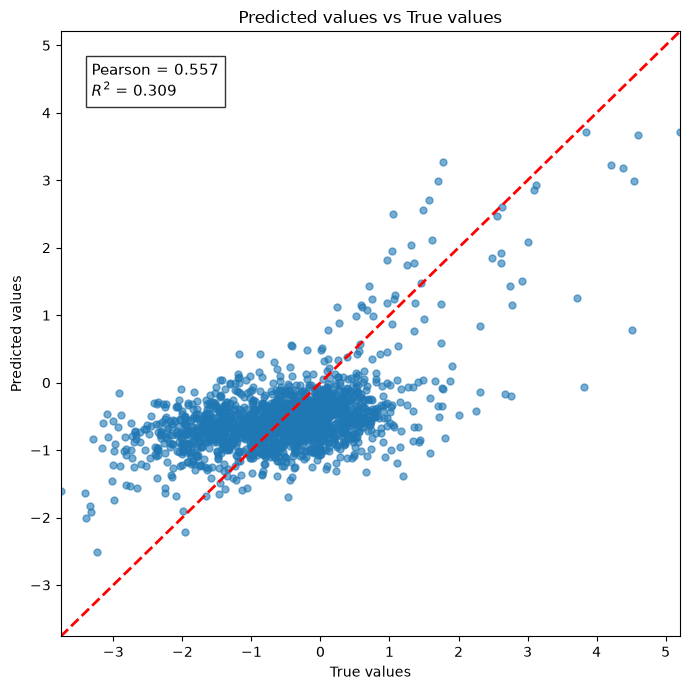

In [140]:
r = pearsonr(test_eval_df["y_true"], test_eval_df["y_pred"])[0]
r2 = r2_score(test_eval_df["y_true"], test_eval_df["y_pred"])

plt.figure(figsize=(7,7))

plt.scatter(
    test_eval_df["y_true"],
    test_eval_df["y_pred"],
    alpha=0.6,
    s=25
)

lims = [
    min(test_eval_df["y_true"].min(), test_eval_df["y_pred"].min()),
    max(test_eval_df["y_true"].max(), test_eval_df["y_pred"].max())
]
plt.plot(lims, lims, "r--", lw=2)

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Predicted values vs True values")

plt.text(
    0.05,
    0.95,
    f"Pearson = {r:.3f}\n$R^2$ = {r2:.3f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

# Part IV — Classification layer

## 21. Select the viral-word prediction threshold

A word is considered truly viral when $y > \log(2)$, meaning future average relative frequency more than doubles.

Threshold selection uses out-of-fold training predictions:

1. Compute the Precision–Recall curve.
2. Keep positive thresholds with precision at least 0.80 (since practical applications benefit more from a small set of highly reliable viral predictions than a larger set containing many false positives).
3. Among those thresholds, maximize recall and break ties using F1.

In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

VIRAL_TRUE_THRESHOLD = np.log(2)
MIN_REQUIRED_PRECISION = 0.80

# 1. Build TRAIN dataframe from OOF predictions

train_eval_df = pd.DataFrame({
    "word": X_train.index,
    "y_true": y_train,
    "y_pred": y_train_pred
}).reset_index(drop=True)

train_eval_df["true_viral"] = train_eval_df["y_true"] > VIRAL_TRUE_THRESHOLD


# 2. Choose prediction threshold on train set only

precision, recall, thresholds = precision_recall_curve(
    train_eval_df["true_viral"],
    train_eval_df["y_pred"]
)

threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
})

threshold_table["f1"] = (
    2 * threshold_table["precision"] * threshold_table["recall"]
    / (threshold_table["precision"] + threshold_table["recall"] + 1e-10)
)

# Keep only thresholds with acceptable precision
candidate_rows = threshold_table[
    (threshold_table["threshold"] > 0) &
    (threshold_table["precision"] >= MIN_REQUIRED_PRECISION)
]

# Among those, choose the one with highest recall
best_row = candidate_rows.sort_values(
    ["recall", "f1"],
    ascending=False
).iloc[0]

chosen_threshold = best_row["threshold"]

print("Chosen threshold from training data:")
print(best_row)


Chosen threshold from training data:
threshold    0.657255
precision    0.800866
recall       0.285935
f1           0.421412
Name: 7098, dtype: float64


## 22. Evaluate the classification layer on held-out test data

In [ ]:
# 3. Apply chosen threshold to test set
test_df = test_eval_df.copy()
test_df["true_viral"] = test_df["y_true"] > VIRAL_TRUE_THRESHOLD
test_df["pred_viral"] = test_df["y_pred"] > chosen_threshold
cmatrix = confusion_matrix(test_df["true_viral"], test_df["pred_viral"])
tn, fp, fn, tp = cmatrix.ravel()

results = pd.DataFrame([{
    "viral_definition": "y_true > log(2)",
    "chosen_prediction_threshold": chosen_threshold,
    "test_words": len(test_df),
    "true_viral_words": int(test_df["true_viral"].sum()),
    "predicted_viral_words": int(test_df["pred_viral"].sum()),
    "TP": int(tp),
    "FP": int(fp),
    "FN": int(fn),
    "TN": int(tn),
    "accuracy": accuracy_score(test_df["true_viral"], test_df["pred_viral"]),
    "precision": precision_score(test_df["true_viral"], test_df["pred_viral"], zero_division=0),
    "recall": recall_score(test_df["true_viral"], test_df["pred_viral"], zero_division=0),
    "f1": f1_score(test_df["true_viral"], test_df["pred_viral"], zero_division=0),
    "roc_auc": roc_auc_score(test_df["true_viral"], test_df["y_pred"]),
    "average_precision": average_precision_score(test_df["true_viral"], test_df["y_pred"]),
}])

results

,viral_definition,chosen_prediction_threshold,test_words,true_viral_words,predicted_viral_words,TP,FP,FN,TN,accuracy,precision,recall,f1,roc_auc,average_precision
0,y_true > log(2),0.657255,1834,135,50,43,7,92,1692,0.94602,0.86,0.318519,0.464865,0.770671,0.485134


## 23. Plot the confusion matrix and Precision–Recall curve

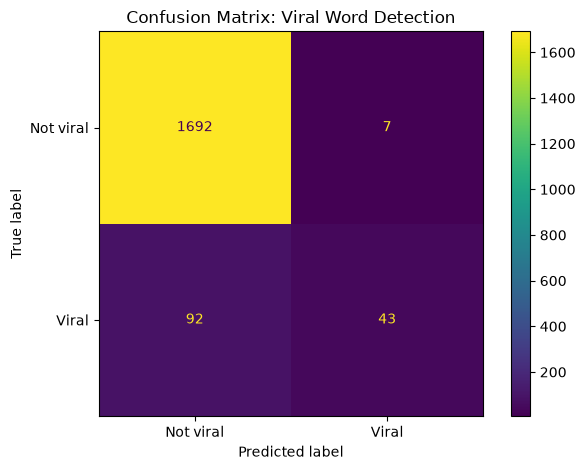

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cmatrix,
    display_labels=["Not viral", "Viral"]
)

disp.plot()
plt.title("Confusion Matrix: Viral Word Detection")
plt.tight_layout()
plt.show()

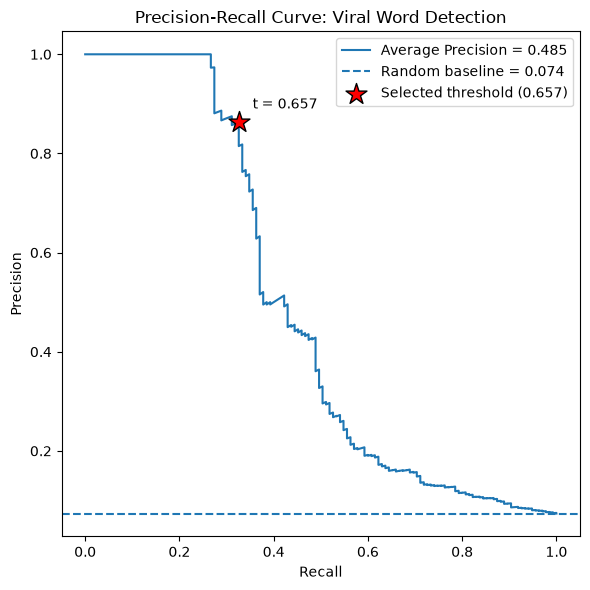

In [141]:
precision, recall, thresholds = precision_recall_curve(
    test_df["true_viral"],
    test_df["y_pred"]
)

ap = average_precision_score(
    test_df["true_viral"],
    test_df["y_pred"]
)

# Find the threshold closest to your chosen threshold
idx = np.argmin(np.abs(thresholds - chosen_threshold))

plt.figure(figsize=(6,6))

plt.plot(
    recall,
    precision,
    label=f"Average Precision = {ap:.3f}"
)

baseline = test_df["true_viral"].mean()
plt.axhline(
    baseline,
    linestyle="--",
    label=f"Random baseline = {baseline:.3f}"
)

# Plot chosen operating point
plt.scatter(
    recall[idx],
    precision[idx],
    color="red",
    marker="*",
    s=250,
    edgecolors="black",
    zorder=10,
    label=f"Selected threshold ({chosen_threshold:.3f})"
)

plt.annotate(
    f"t = {chosen_threshold:.3f}",
    (recall[idx], precision[idx]),
    xytext=(10,10),
    textcoords="offset points"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Viral Word Detection")
plt.legend()
plt.tight_layout()
plt.show()